In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Load Data ─────────────────────────────────────────────
df_energy = pd.read_csv("eirgrid_renewable_2026.csv", parse_dates=["datetime"])
df_energy["hour"] = df_energy["datetime"].dt.hour
df_energy["month"] = df_energy["datetime"].dt.month
df_energy["date"] = df_energy["datetime"].dt.date.astype(str)

print(f"Total records: {len(df_energy)}")
print(f"Date range: {df_energy['datetime'].min()} → {df_energy['datetime'].max()}")
df_energy.describe()

Total records: 11516
Date range: 2026-01-01 00:00:00 → 2026-04-30 23:45:00


,datetime,wind_mw,solar_mw,total_demand_mw,wind_penetration,solar_penetration,renewable_score,hour,month
count,11516,11516.000000,11516.000000,11516.000000,11516.000000,11516.000000,11516.000000,11516.000000,11516.000000
mean,2026-03-01 23:38:57.843001088,1634.123409,115.180390,4306.735036,0.382560,0.027591,0.410151,11.503647,2.499826
min,2026-01-01 00:00:00,0.000000,0.000000,3181.730000,0.000000,0.000000,0.004400,0.000000,1.000000
25%,2026-01-30 23:41:15,764.562500,0.130000,3823.920000,0.171293,0.000033,0.204900,6.000000,1.000000
50%,2026-03-01 23:22:30,1651.385000,4.270000,4247.635000,0.377760,0.001012,0.412800,12.000000,3.000000
75%,2026-04-01 00:03:45,2465.617500,140.372500,4759.530000,0.576730,0.030010,0.603900,18.000000,4.000000
max,2026-04-30 23:45:00,3877.810000,1118.210000,5899.270000,0.883349,0.330377,0.883300,23.000000,4.000000
std,NaN,971.878597,205.679197,568.675648,0.228723,0.052045,0.227414,6.920922,1.125669


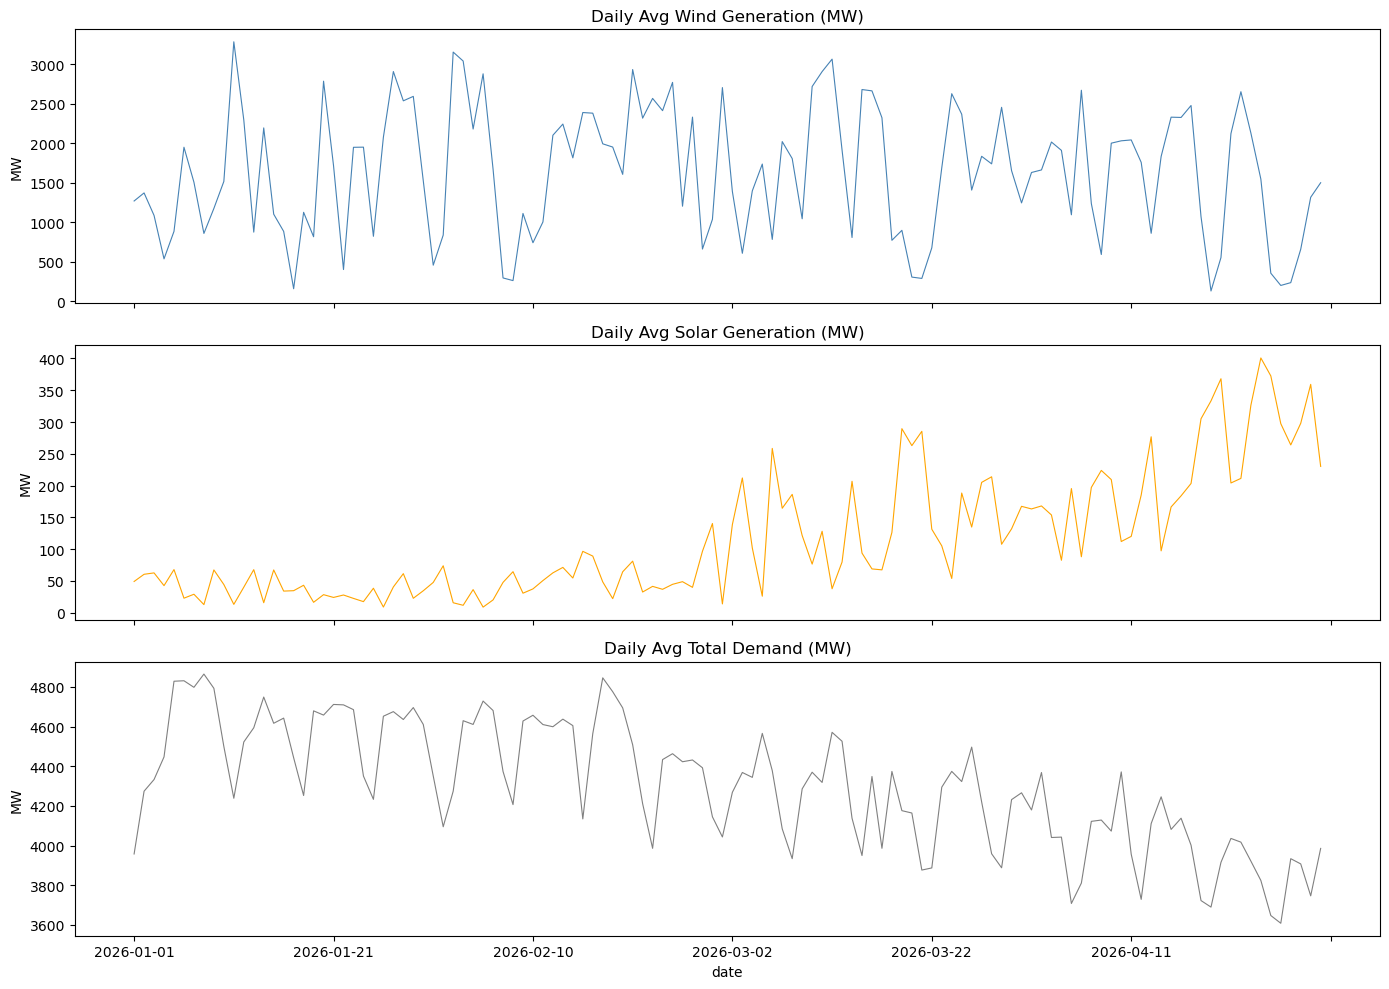

In [3]:
# ── 1. Wind & Solar Generation over Time ──────────────────
daily = df_energy.groupby("date")[["wind_mw", "solar_mw", "total_demand_mw"]].mean()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

daily["wind_mw"].plot(ax=axes[0], color="steelblue", linewidth=0.8)
axes[0].set_title("Daily Avg Wind Generation (MW)")
axes[0].set_ylabel("MW")

daily["solar_mw"].plot(ax=axes[1], color="orange", linewidth=0.8)
axes[1].set_title("Daily Avg Solar Generation (MW)")
axes[1].set_ylabel("MW")

daily["total_demand_mw"].plot(ax=axes[2], color="gray", linewidth=0.8)
axes[2].set_title("Daily Avg Total Demand (MW)")
axes[2].set_ylabel("MW")

plt.tight_layout()
plt.savefig("generation_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

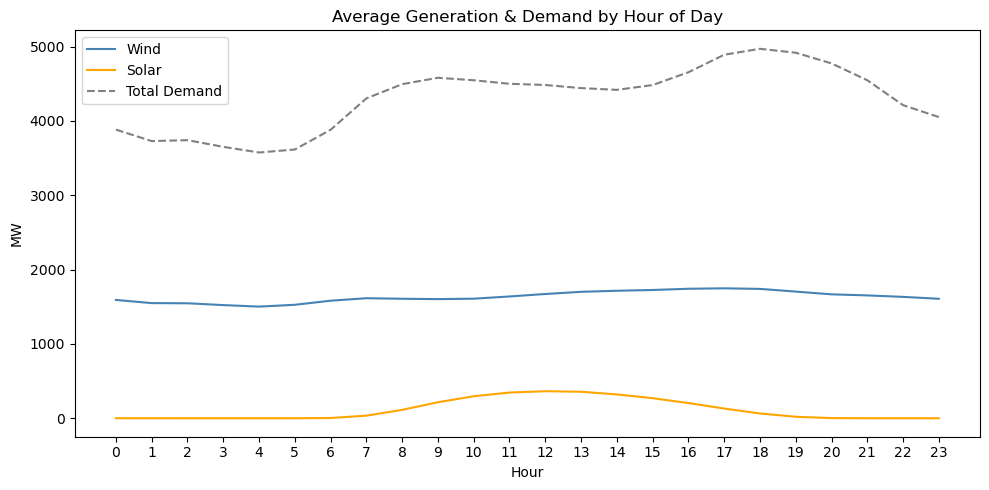

In [4]:
# ── 2. Average Hourly Pattern ─────────────────────────────
hourly = df_energy.groupby("hour")[["wind_mw", "solar_mw", "total_demand_mw"]].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hourly.index, hourly["wind_mw"], label="Wind", color="steelblue")
ax.plot(hourly.index, hourly["solar_mw"], label="Solar", color="orange")
ax.plot(hourly.index, hourly["total_demand_mw"], label="Total Demand",
        color="gray", linestyle="--")
ax.set_title("Average Generation & Demand by Hour of Day")
ax.set_xlabel("Hour")
ax.set_ylabel("MW")
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.savefig("hourly_pattern.png", dpi=150, bbox_inches="tight")
plt.show()

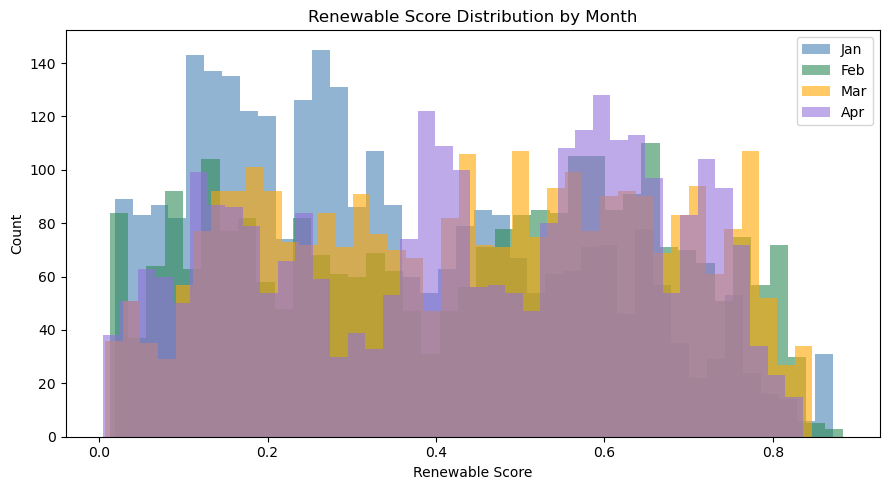

In [5]:
# ── 3. Renewable Score Distribution by Month ──────────────
month_names = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr"}

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["steelblue", "seagreen", "orange", "mediumpurple"]
for i, month in enumerate([1, 2, 3, 4]):
    subset = df_energy[df_energy["month"] == month]["renewable_score"]
    ax.hist(subset, bins=40, alpha=0.6,
            label=month_names[month], color=colors[i])

ax.set_title("Renewable Score Distribution by Month")
ax.set_xlabel("Renewable Score")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("renewable_score_dist.png", dpi=150, bbox_inches="tight")
plt.show()

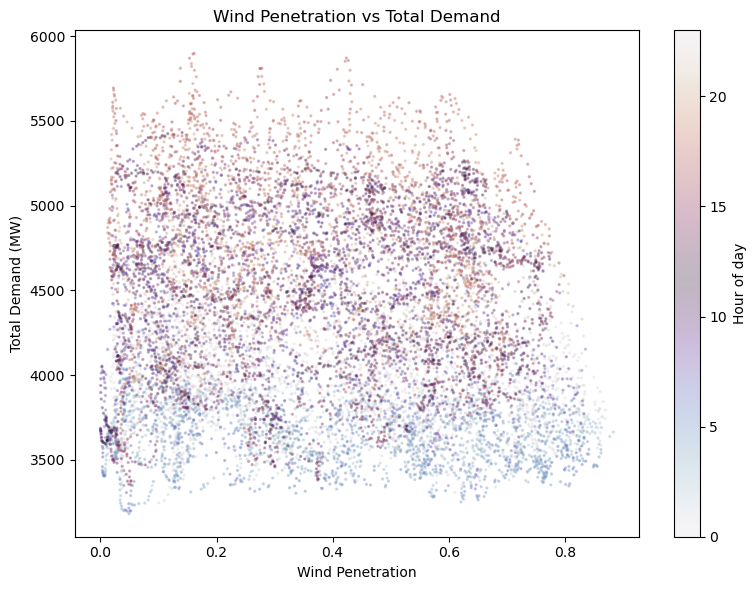

In [6]:
# ── 4. Wind Penetration vs Total Demand ───────────────────
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(df_energy["wind_penetration"], df_energy["total_demand_mw"],
                c=df_energy["hour"], cmap="twilight", alpha=0.3, s=2)
plt.colorbar(sc, ax=ax, label="Hour of day")
ax.set_title("Wind Penetration vs Total Demand")
ax.set_xlabel("Wind Penetration")
ax.set_ylabel("Total Demand (MW)")
plt.tight_layout()
plt.savefig("wind_vs_demand.png", dpi=150, bbox_inches="tight")
plt.show()

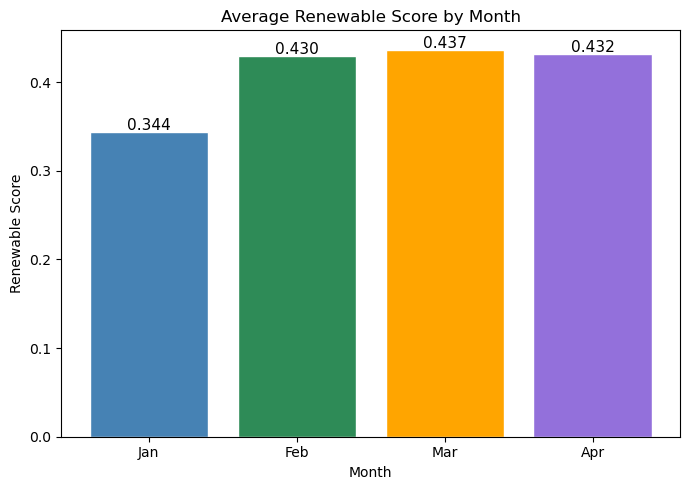

In [7]:
# ── 5. Monthly Avg Renewable Score (bar chart) ────────────
monthly_avg = df_energy.groupby("month")["renewable_score"].mean()
monthly_avg.index = [month_names[m] for m in monthly_avg.index]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(monthly_avg.index, monthly_avg.values,
              color=colors, edgecolor="white")
ax.set_title("Average Renewable Score by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Renewable Score")
for bar, val in zip(bars, monthly_avg.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + 0.002, f"{val:.3f}", ha="center", fontsize=11)
plt.tight_layout()
plt.savefig("monthly_renewable_score.png", dpi=150, bbox_inches="tight")
plt.show()